<a href="https://colab.research.google.com/github/springboardmentor891v/CreditPathAI/blob/Vaibhavi/Evaluation_LoanDefault.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [ ]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/CreditPathAI/LOAN DATASET.csv')
print("Dataset loaded successfully!")

# Display the first few rows
print("First 5 rows of the dataset:")
print(df.head())

# Get a concise summary of the dataframe
print("\nDataset Information:")
df.info()

Dataset loaded successfully!
First 5 rows of the dataset:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1       

In [ ]:
# Missing values per column
print("Missing values:\n", df.isnull().sum())


Missing values:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


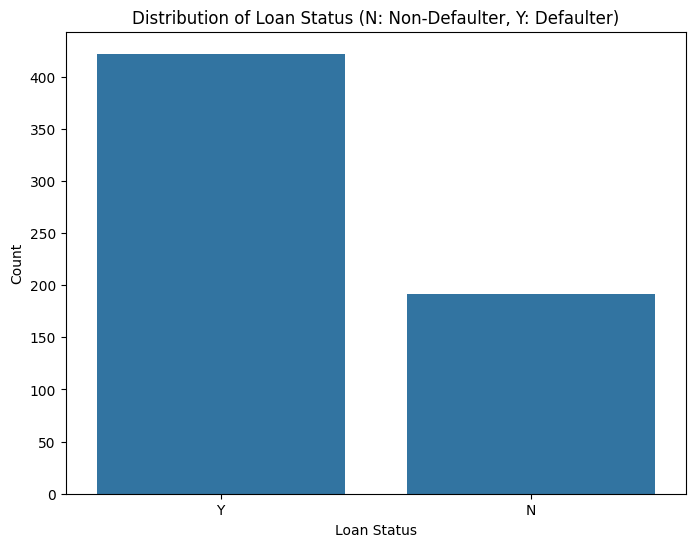


Loan Status Counts:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Loan Status Proportions:
Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


In [ ]:
# Plot the distribution of the target variable
plt.figure(figsize=(8, 6))
sns.countplot(x='Loan_Status', data=df)
plt.title('Distribution of Loan Status (N: Non-Defaulter, Y: Defaulter)')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

# Print the exact counts
print("\nLoan Status Counts:")
print(df['Loan_Status'].value_counts())
print("\nLoan Status Proportions:")
print(df['Loan_Status'].value_counts(normalize=True) * 100)

In [ ]:
# Drop the ID column
df.drop('Loan_ID', axis=1, inplace=True)
print("Loan_ID column dropped.")

Loan_ID column dropped.


In [ ]:
# Identify categorical columns (dtype='object')
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"\nCategorical columns to be encoded: {list(categorical_cols)}")

# Perform one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nShape of the dataframe after one-hot encoding:", df_encoded.shape)
print("First 5 rows of the encoded dataframe:")
print(df_encoded.head())


Categorical columns to be encoded: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

Shape of the dataframe after one-hot encoding: (614, 15)
First 5 rows of the encoded dataframe:
   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History  Gender_Male  Married_Yes  Dependents_1  Dependents_2  \
0             1.0         True        False         False         False   
1             1.0         True         True          True         False   
2             1.0         True         True         False         False   
3             1.0         True         Tru

In [ ]:
# Separate features (X) and target (y)
X = df_encoded.drop('Loan_Status_Y', axis=1)
y = df_encoded['Loan_Status_Y']

print("\nFeatures (X) shape:", X.shape)
print("Target (y) shape:", y.shape)


Features (X) shape: (614, 14)
Target (y) shape: (614,)


Train-Test split

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (491, 14)
Testing set shape: (123, 14)


In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the scaler fitted on the training data
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling applied successfully.")


Feature scaling applied successfully.


Handling missing values

In [ ]:
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)


In [ ]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data only
print(f"Original training class distribution:\n{y_train.value_counts()}")

# Import SimpleImputer
from sklearn.impute import SimpleImputer

# Initialize an imputer (e.g., using the mean strategy)
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on the scaled training data and transform it
X_train_imputed = imputer.fit_transform(X_train_scaled)

# Apply SMOTE to the imputed training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_imputed, y_train)

print(f"\nResampled training class distribution:\n{y_train_resampled.value_counts()}")

Original training class distribution:
Loan_Status_Y
True     337
False    154
Name: count, dtype: int64

Resampled training class distribution:
Loan_Status_Y
True     337
False    337
Name: count, dtype: int64


In [ ]:
# Initialize the models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42),
}

# Train and evaluate each model
for name, model in models.items():
    print(f"\n--- Training {name} ---")
    # Train the model on the resampled training data
    model.fit(X_train_resampled, y_train_resampled)
    print(f"{name} trained successfully.")



--- Training Logistic Regression ---
Logistic Regression trained successfully.

--- Training Decision Tree ---
Decision Tree trained successfully.

--- Training Random Forest ---
Random Forest trained successfully.

--- Training Extra Trees ---
Extra Trees trained successfully.

--- Training Gradient Boosting ---
Gradient Boosting trained successfully.

--- Training K-Nearest Neighbors ---
K-Nearest Neighbors trained successfully.

--- Training Naive Bayes ---
Naive Bayes trained successfully.

--- Training XGBoost ---
XGBoost trained successfully.

--- Training LightGBM ---
[LightGBM] [Info] Number of positive: 337, number of negative: 337
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000148 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 698
[LightGBM] [Info] Number of data points in the train set: 674, number of used features: 14


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:56:18] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Evaluation for Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

       False       0.68      0.66      0.67        38
        True       0.85      0.86      0.85        85

    accuracy                           0.80       123
   macro avg       0.76      0.76      0.76       123
weighted avg       0.80      0.80      0.80       123

ROC-AUC Score: 0.8545


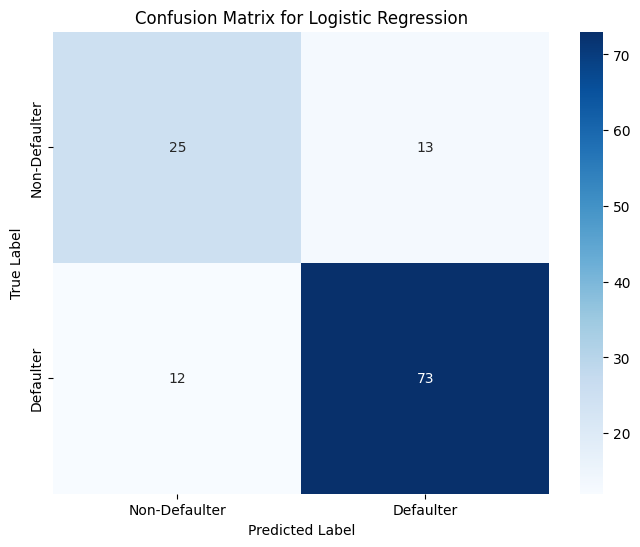


--- Evaluation for Decision Tree ---
Classification Report:
              precision    recall  f1-score   support

       False       0.60      0.66      0.62        38
        True       0.84      0.80      0.82        85

    accuracy                           0.76       123
   macro avg       0.72      0.73      0.72       123
weighted avg       0.76      0.76      0.76       123

ROC-AUC Score: 0.7289


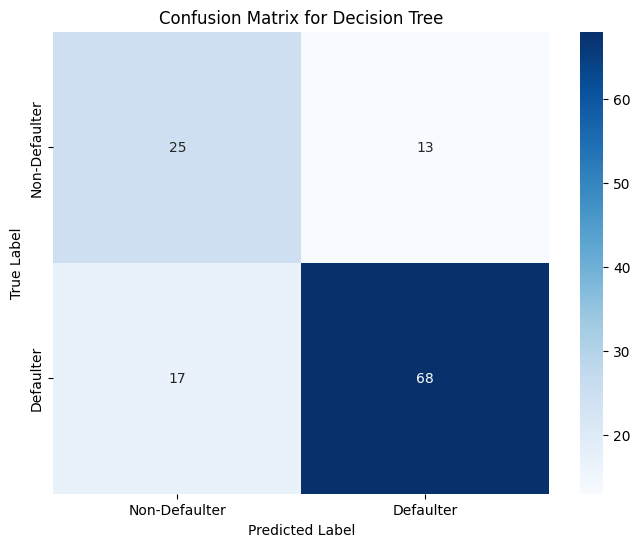


--- Evaluation for Random Forest ---
Classification Report:
              precision    recall  f1-score   support

       False       0.69      0.66      0.68        38
        True       0.85      0.87      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.76      0.77       123
weighted avg       0.80      0.80      0.80       123

ROC-AUC Score: 0.8050


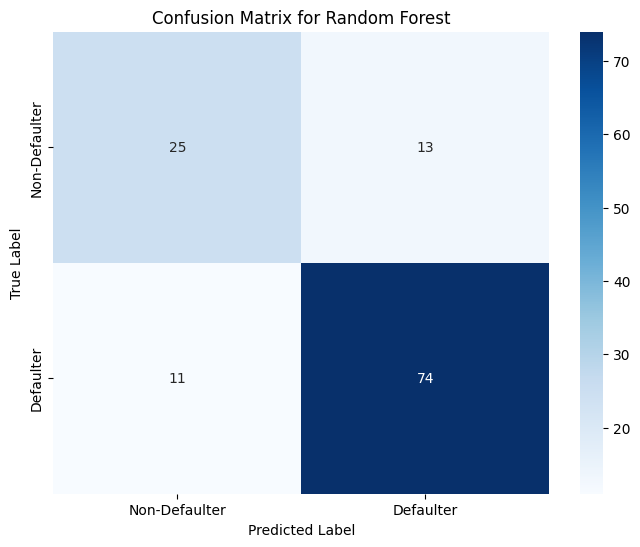


--- Evaluation for Extra Trees ---
Classification Report:
              precision    recall  f1-score   support

       False       0.73      0.63      0.68        38
        True       0.84      0.89      0.87        85

    accuracy                           0.81       123
   macro avg       0.79      0.76      0.77       123
weighted avg       0.81      0.81      0.81       123

ROC-AUC Score: 0.7904


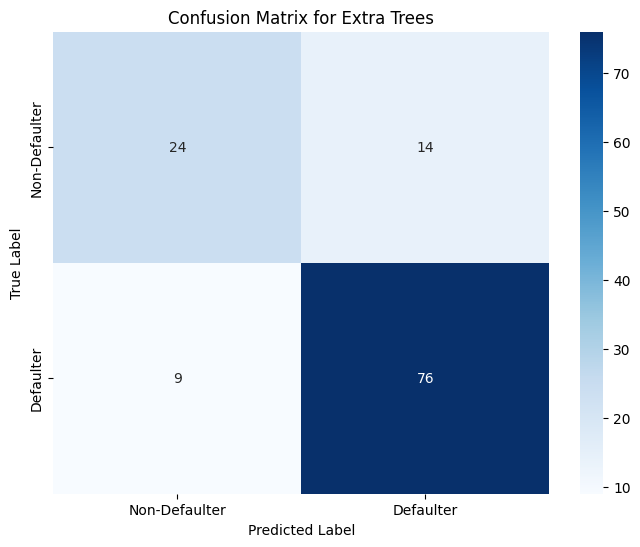


--- Evaluation for Gradient Boosting ---
Classification Report:
              precision    recall  f1-score   support

       False       0.72      0.61      0.66        38
        True       0.84      0.89      0.86        85

    accuracy                           0.80       123
   macro avg       0.78      0.75      0.76       123
weighted avg       0.80      0.80      0.80       123

ROC-AUC Score: 0.7904


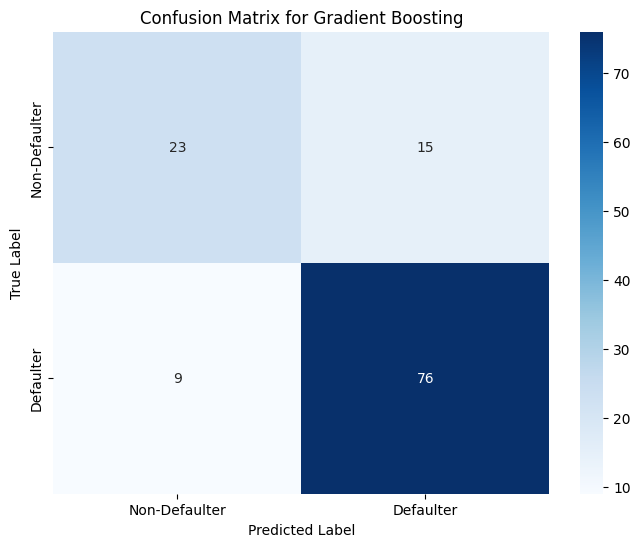


--- Evaluation for K-Nearest Neighbors ---
Classification Report:
              precision    recall  f1-score   support

       False       0.56      0.61      0.58        38
        True       0.82      0.79      0.80        85

    accuracy                           0.73       123
   macro avg       0.69      0.70      0.69       123
weighted avg       0.74      0.73      0.73       123

ROC-AUC Score: 0.7542


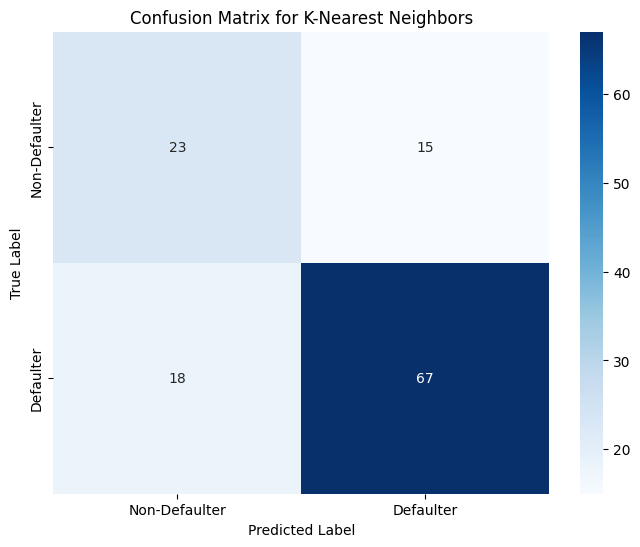


--- Evaluation for Naive Bayes ---
Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.58      0.71        38
        True       0.84      0.98      0.90        85

    accuracy                           0.85       123
   macro avg       0.88      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123

ROC-AUC Score: 0.7969


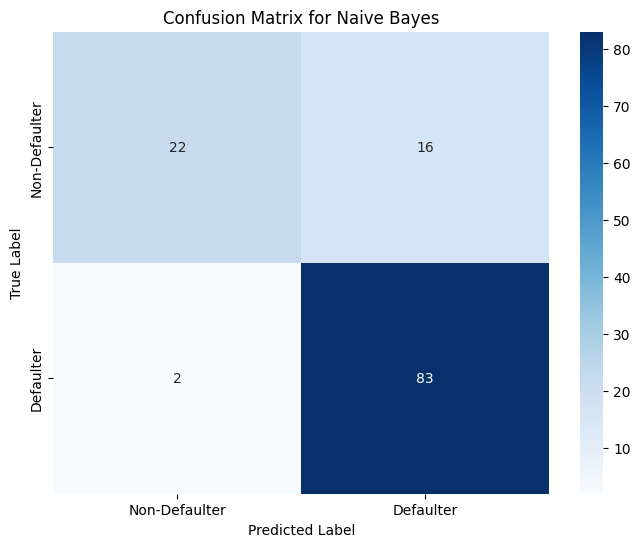


--- Evaluation for XGBoost ---
Classification Report:
              precision    recall  f1-score   support

       False       0.63      0.68      0.66        38
        True       0.85      0.82      0.84        85

    accuracy                           0.78       123
   macro avg       0.74      0.75      0.75       123
weighted avg       0.79      0.78      0.78       123

ROC-AUC Score: 0.8121


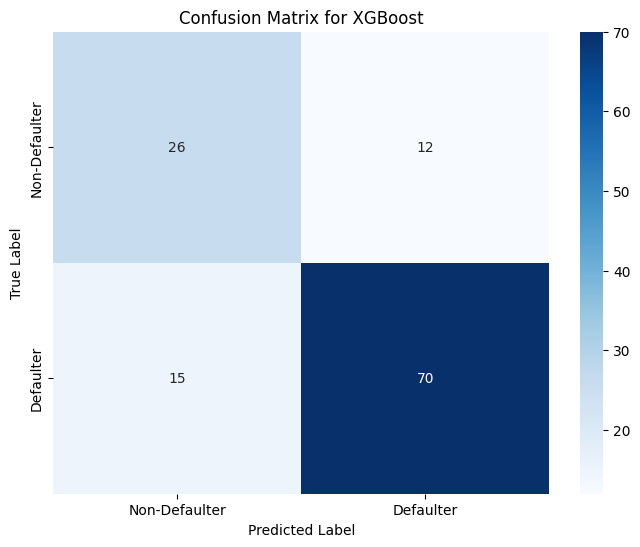


--- Evaluation for LightGBM ---
Classification Report:
              precision    recall  f1-score   support

       False       0.68      0.68      0.68        38
        True       0.86      0.86      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.77      0.77       123
weighted avg       0.80      0.80      0.80       123

ROC-AUC Score: 0.7975


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


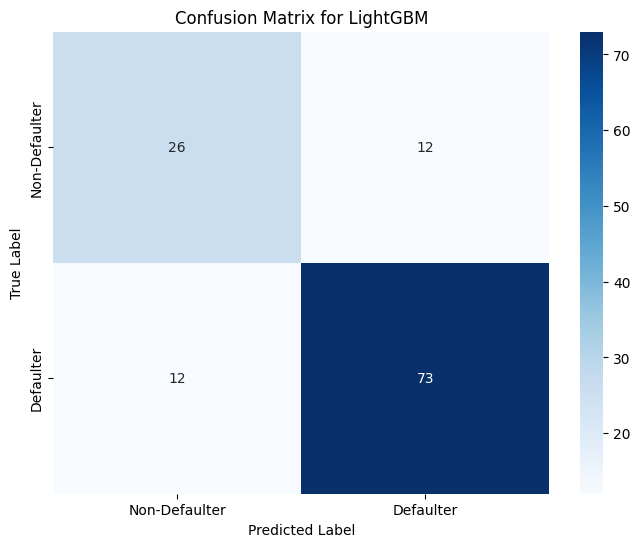

In [ ]:
# Apply the imputer to the test data
X_test_imputed = imputer.transform(X_test_scaled)


for name, model in models.items():
    print(f"\n--- Evaluation for {name} ---")

    # Make predictions on the test set
    y_pred = model.predict(X_test_imputed)
    y_pred_proba = model.predict_proba(X_test_imputed)[:, 1] # for ROC-AUC

    # Print Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Print ROC-AUC Score
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC-AUC Score: {auc_score:.4f}")

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Defaulter', 'Defaulter'], yticklabels=['Non-Defaulter', 'Defaulter'])
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


--- Evaluating Logistic Regression ---


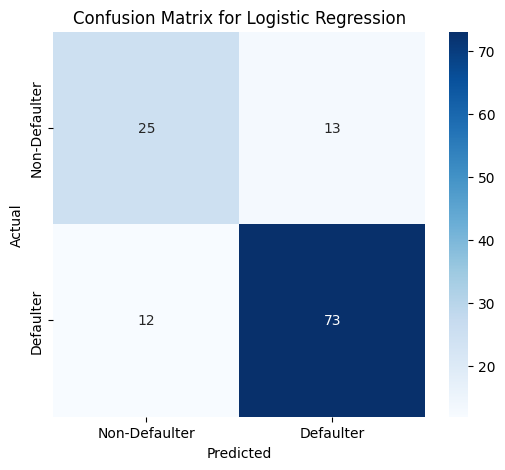


--- Evaluating KNN ---


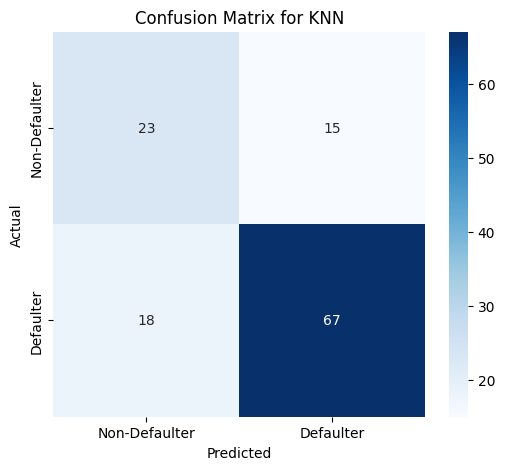


--- Evaluating Decision Tree ---


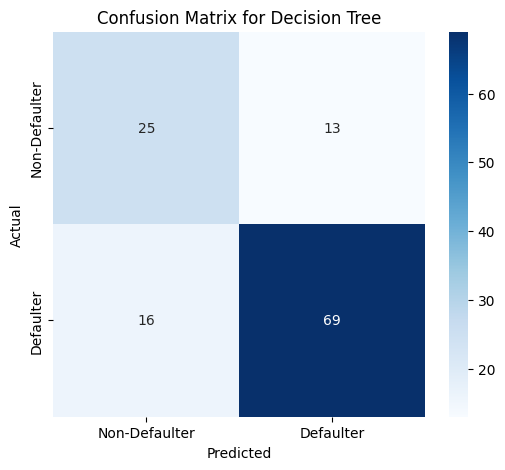


--- Evaluating Random Forest ---


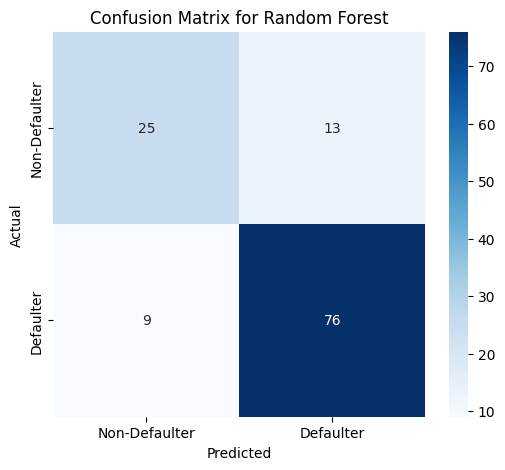


--- Evaluating Gradient Boosting ---


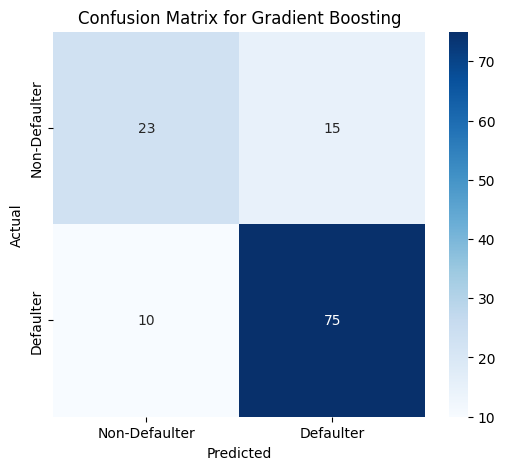


--- Evaluating XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:26:53] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


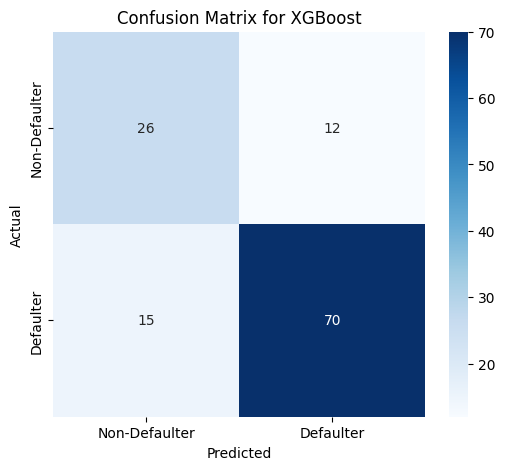


--- Evaluating Linear SVM ---


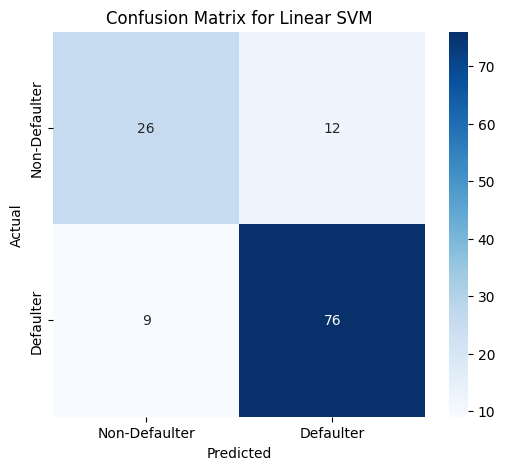

+---------------------+-------------+------------+---------------+---------------+-------------+------------+
| Model               |   Train Acc |   Test Acc |   Sensitivity |   Specificity |   Precision |   F1-Score |
+=====================+=============+============+===============+===============+=============+============+
| Logistic Regression |      0.7107 |     0.7967 |        0.8588 |        0.6579 |      0.8488 |     0.8538 |
+---------------------+-------------+------------+---------------+---------------+-------------+------------+
| KNN                 |      0.8531 |     0.7317 |        0.7882 |        0.6053 |      0.8171 |     0.8024 |
+---------------------+-------------+------------+---------------+---------------+-------------+------------+
| Decision Tree       |      1      |     0.7642 |        0.8118 |        0.6579 |      0.8415 |     0.8263 |
+---------------------+-------------+------------+---------------+---------------+-------------+------------+
| Random F

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns

results = []


y_train_resampled_int = y_train_resampled.astype(int)

for name, model in models: # Iterate over the list of tuples
    print(f"\n--- Evaluating {name} ---")
    try:
        # Fit the model on resampled training data
        model.fit(X_train_resampled, y_train_resampled)

        # Predictions
        y_train_pred = model.predict(X_train_resampled) # Predict on resampled training data
        y_test_pred = model.predict(X_test_imputed)

        # Convert predictions to integers for metric calculation if they are boolean
        if y_test_pred.dtype == bool:
            y_test_pred_int = y_test_pred.astype(int)
        else:
            y_test_pred_int = y_test_pred

        if y_train_pred.dtype == bool:
            y_train_pred_int = y_train_pred.astype(int)
        else:
            y_train_pred_int = y_train_pred


        # Calculate metrics using integer targets and predictions
        train_acc = accuracy_score(y_train_resampled_int, y_train_pred_int) # Use resampled training target
        test_acc = accuracy_score(y_test_int, y_test_pred_int)

        # Confusion matrix to get Sensitivity and Specificity
        tn, fp, fn, tp = confusion_matrix(y_test_int, y_test_pred_int).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        # Precision & F1-Score (handle potential division by zero)
        precision = precision_score(y_test_int, y_test_pred_int, average='binary', pos_label=1) if (tp + fp) > 0 else 0
        f1 = f1_score(y_test_int, y_test_pred_int, average='binary', pos_label=1) if (tp + fn) > 0 else 0


        # Append results
        results.append([name, round(train_acc, 4), round(test_acc, 4), round(sensitivity, 4), round(specificity, 4), round(precision, 4), round(f1, 4)])

        # Optional: Plot confusion matrix
        plt.figure(figsize=(6, 5))
        sns.heatmap(confusion_matrix(y_test_int, y_test_pred_int), annot=True, fmt='d',
                    cmap='Blues', xticklabels=['Non-Defaulter','Defaulter'],
                    yticklabels=['Non-Defaulter','Defaulter'])
        plt.title(f'Confusion Matrix for {name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

    except Exception as e:
        print(f"Error evaluating {name}: {e}")
        results.append([name, "Error", "Error", "Error", "Error", "Error", "Error"])


# Display all results in a table
headers = ["Model", "Train Acc", "Test Acc", "Sensitivity", "Specificity", "Precision", "F1-Score"]
print(tabulate(results, headers=headers, tablefmt="grid"))